# News-Driven Stock Direction Classifier

**Pipeline**: `BERT (NLP) → 1D CNN (Deep Learning) → ML Ensemble / Fine-tuned Head`

Predicts whether a stock moves **up or down** over the next **1, 5, or 20 trading days** based on a financial news headline.

---

## Experiments

| # | Model | NLP Algorithm | Deep Learning | Machine Learning | BERT Layers | Targets |
|---|---|---|---|---|---|---|
| 1 | Frozen BERT-base + Ensemble | BERT tokenizer, WordPiece embeddings | 1D CNN (bigram/trigram/4-gram) | LR + LightGBM + CatBoost (soft vote) | All 12 frozen | 1d |
| 2 | BERT-base fine-tuned | BERT tokenizer, WordPiece embeddings | BERT encoder + 1D CNN | Linear head + BCEWithLogitsLoss | Last 2 unfrozen | 1d, 5d, 20d |
| 3 | FinBERT fine-tuned | FinBERT tokenizer, financial embeddings | FinBERT encoder + 1D CNN | Linear head + BCEWithLogitsLoss | Last 2 unfrozen | 1d, 5d, 20d |

---

## Technology Stack

| Layer | Algorithm | Library | Role |
|---|---|---|---|
| **NLP** | BERT tokenizer (WordPiece) | HuggingFace Transformers | Converts headline text → token IDs + attention masks |
| **NLP** | BERT / FinBERT encoder | HuggingFace Transformers | Contextual token embeddings (768-dim) |
| **Deep Learning** | 1D Convolutional Neural Network | PyTorch `nn.Conv1d` | Extracts bigram/trigram/4-gram phrase features |
| **Deep Learning** | Global Max Pooling | PyTorch | Collapses sequence → fixed 768-dim vector |
| **Deep Learning** | Linear head + BCEWithLogitsLoss | PyTorch | End-to-end fine-tuned binary classifier |
| **Machine Learning** | Logistic Regression | scikit-learn | Linear baseline on CNN features |
| **Machine Learning** | LightGBM | LightGBM | Gradient boosted trees |
| **Machine Learning** | CatBoost | CatBoost | Ordered gradient boosting |
| **Machine Learning** | Soft Voting Ensemble | numpy | Average probabilities across all 3 models |
| **Tuning** | Optuna TPE | Optuna | Bayesian hyperparameter search for LightGBM |

---

## Architecture

```
News headline (text)
       |
       v
[ NLP: BERT Tokenizer ]
  WordPiece tokenization -> token IDs + attention masks
       |
       v
[ NLP + Deep Learning: BERT Encoder ]
  Frozen path  : all 12 layers fixed  (fast feature extractor)
  Fine-tuned   : layers 0-9 frozen, layers 10-11 trainable
  Output       : (batch, 64 tokens, 768 dims)
       |
       v
[ Deep Learning: 1D CNN ]
  kernel=2 -> bigrams  ("beats estimates")
  kernel=3 -> trigrams ("raises full year")
  kernel=4 -> 4-grams  ("miss on earnings")
  Global Max Pool + concat -> 768-dim vector
       |
       v
[ Machine Learning: Prediction Head ]
  Frozen path  -> Soft Voting Ensemble
                  (LR + LightGBM + CatBoost)
  Fine-tuned   -> Linear layer + BCEWithLogitsLoss
       |
       v
    UP (1) / DOWN (0)
```

---

## Notebook Sections

| # | Section | What it does |
|---|---|---|
| 1 | Data Loading | Loads 1d/5d/20d returns; handles timezone-aware Postgres timestamps |
| 2 | EDA | Class balance, headline lengths, articles per year |
| 3 | Model Architecture | `ArticleDataset`, `ArticleDatasetLabelled`, `BertCNN`, `BertCNNClassifier` |
| 4 | Feature Extraction | Frozen BERT+CNN on all headlines — AMP + large batches for GPU throughput |
| 5 | Train/Test Split | Temporal split: train before 2024, test from 2024 (no data leakage) |
| 6 | ML Ensemble | LR + LightGBM + CatBoost + soft voting on cached CNN features |
| 7 | Evaluation | Confusion matrices, classification reports, AUC-ROC |
| 8 | Optuna Tuning | 30-trial Bayesian search over LightGBM hyperparameters |
| 9 | Optuna Visualization | AUC-ROC over trials, hyperparameter importance chart |
| 10 | Baseline Results | Frozen BERT ensemble comparison table + ROC curves |
| 11 | Fine-Tuning Functions | `train_epoch()` with AMP + gradient clipping; `eval_model()` |
| 12 | Fine-Tuning Comparison | BERT-base + FinBERT × 1d/5d/20d = 6 runs with layer-wise LR decay |
| 13 | Full Results Table | All models × all targets sorted 1d→5d→20d, best highlighted green |

---

## Why this architecture?

| Choice | Reason |
|---|---|
| **Freeze most BERT layers** | Early layers learn universal syntax — no benefit updating on noisy stock labels |
| **Unfreeze last 2 layers** | Later layers learn task semantics — these adapt to financial headline patterns |
| **Layer-wise LR decay** | BERT layers: `2e-5`; CNN + head: `2e-4` (10× larger for new layers) |
| **1D CNN over LSTM** | Faster on GPU, parallelisable, captures local phrase patterns just as effectively |
| **3-model soft voting ensemble** | LR (linear) + LightGBM (boosting) + CatBoost (ordered boosting) — diverse inductive biases reduce variance |
| **FinBERT vs BERT-base** | FinBERT pretrained on 4.9B financial words — tests if domain pretraining helps |
| **20d target vs 1d** | 1d dominated by noise; 20d captures full post-earnings drift (PEAD) |
| **AMP (FP16) on RTX 4090** | Activates Tensor Cores — ~2× throughput; halves VRAM per activation |
| **Temporal train/test split** | Random split leaks future patterns into training — critical in financial ML |


In [1]:
# ── Install dependencies (run once, then comment out) ──────────────────────────
# !pip install transformers torch lightgbm catboost optuna psycopg2-binary sqlalchemy tqdm seaborn scikit-learn


In [2]:
# ── Imports ────────────────────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import psycopg2

# Deep Learning
import torch
import torch.nn as nn
from torch.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader

# NLP
from transformers import BertTokenizer, BertModel

# ML — Scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, accuracy_score, f1_score
)

# ML — Gradient boosting
import lightgbm as lgb
from catboost import CatBoostClassifier

# Hyperparameter tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {device_name}")
print(f"CUDA     : {torch.cuda.is_available()}")


PyTorch  : 2.6.0+cu124
Device   : NVIDIA GeForce RTX 4090
CUDA     : True


In [ ]:
# ── Configuration ──────────────────────────────────────────────────────────────
DB_URL = os.getenv("PG_DB_URL")  

BERT_MODELS = {
    "BERT-base": "bert-base-uncased",
    "FinBERT"  : "ProsusAI/finbert",
}

TARGETS = {
    "1d" : "fwd_ret_1d",
    "5d" : "fwd_ret_5d",
    "20d": "fwd_ret_20d",
}

MAX_LEN      = 64
NUM_FILTERS  = 256
KERNEL_SIZES = [2, 3, 4]

# ── GPU throughput ────────────────────────────────────────────────────────────
# EXTRACT_BATCH=512 : fills more VRAM per step (no gradients stored during extraction)
# FINETUNE_BATCH=128: ~14 GB VRAM with AMP (FP16); raise to 256 if headroom allows
# USE_AMP=True      : automatic mixed precision — FP16 activations use Tensor Cores
EXTRACT_BATCH    = 512
FINETUNE_BATCH   = 512
USE_AMP          = True

UNFREEZE_LAST_N  = 2
FINETUNE_LR      = 2e-5
FINETUNE_EPOCHS  = 1
MAX_TRAIN_SAMPLES = 100_000

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
FEAT_PATH  = "features.npy"
LABEL_PATH = "labels.npy"
SPLIT_DATE = "2024-01-01"
N_TRIALS   = 5

print("Config loaded")
print(f"  Models        : {list(BERT_MODELS.keys())}")
print(f"  Targets       : {list(TARGETS.keys())}")
print(f"  Extract batch : {EXTRACT_BATCH}  |  Finetune batch: {FINETUNE_BATCH}")
print(f"  Mixed precision (AMP): {USE_AMP}")
print(f"  Device        : {DEVICE}")


Config loaded
  Models        : ['BERT-base', 'FinBERT']
  Targets       : ['1d', '5d', '20d']
  Extract batch : 512  |  Finetune batch: 128
  Mixed precision (AMP): True
  Device        : cuda


In [4]:
# ── Section 1: Data Loading ────────────────────────────────────────────────────
# Load all three return horizons (1d, 5d, 20d) in one query so we don't hit the
# DB multiple times. Each row = one (article, symbol) pair with all three targets.

from sqlalchemy import create_engine

def load_data(db_url: str) -> pd.DataFrame:
    """
    Query news_contrarian.features for headlines + forward returns at 3 horizons.
    Returns a single DataFrame used by both the frozen-BERT baseline and fine-tuning.
    """
    engine = create_engine(db_url)

    query = """
        SELECT
            article_date,
            symbol,
            title,
            fwd_ret_1d,    -- next-day return   (noisiest target)
            fwd_ret_5d,    -- 5-day return       (medium horizon)
            fwd_ret_20d    -- 20-day return      (cleanest PEAD signal)
        FROM news_contrarian.features
        WHERE title IS NOT NULL
          AND fwd_ret_1d  IS NOT NULL
          AND article_date >= '2019-01-01'
        ORDER BY article_date
    """

    df = pd.read_sql(query, engine)

    # article_date comes back as object dtype with mixed UTC offsets on large datasets.
    # utc=True normalises all offsets to UTC; tz_convert(None) strips tzinfo entirely.
    df['article_date'] = pd.to_datetime(df['article_date'], utc=True).dt.tz_convert(None)

    # Binary direction labels for all three horizons
    # NaN in 5d/20d is expected for the most recent rows (forward window not yet complete)
    df['label_1d']  = (df['fwd_ret_1d']  > 0).astype(int)
    df['label_5d']  = (df['fwd_ret_5d']  > 0).astype('Int64')   # Int64 = nullable integer
    df['label_20d'] = (df['fwd_ret_20d'] > 0).astype('Int64')

    print(f'Loaded    : {len(df):,} articles')
    print(f'Symbols   : {df["symbol"].nunique():,} unique')
    print(f'Date range: {df["article_date"].min().date()} → {df["article_date"].max().date()}')
    print(f'\nClass balance per target:')
    for label_col, ret_col in [('label_1d','fwd_ret_1d'),('label_5d','fwd_ret_5d'),('label_20d','fwd_ret_20d')]:
        valid = df[label_col].notna()
        up_pct = df.loc[valid, label_col].mean()
        print(f'  {ret_col:12s}: {up_pct:.1%} up  ({valid.sum():,} rows)')
    return df


df = load_data(DB_URL)
df.head()

Loaded    : 1,442,674 articles
Symbols   : 6,684 unique
Date range: 2021-01-05 → 2026-05-05

Class balance per target:
  fwd_ret_1d  : 48.8% up  (1,442,674 rows)
  fwd_ret_5d  : 49.3% up  (1,442,674 rows)
  fwd_ret_20d : 48.4% up  (1,442,674 rows)


,article_date,symbol,title,fwd_ret_1d,fwd_ret_5d,fwd_ret_20d,label_1d,label_5d,label_20d
0,2021-01-05 14:15:00,GS,2021 Begins With a More Than 1% Pullback,0.055594,0.096457,0.063194,1,1,1
1,2021-01-05 14:15:00,FITB,2021 Begins With a More Than 1% Pullback,0.108604,0.117772,0.131523,1,1,1
2,2021-01-05 14:15:00,XOM,2021 Begins With a More Than 1% Pullback,0.012385,0.090295,0.088268,1,1,1
3,2021-01-05 14:15:00,CLF,2021 Begins With a More Than 1% Pullback,0.104375,0.111250,-0.000625,1,1,0
4,2021-01-05 14:15:00,C,2021 Begins With a More Than 1% Pullback,0.023725,0.036750,-0.032253,1,1,0


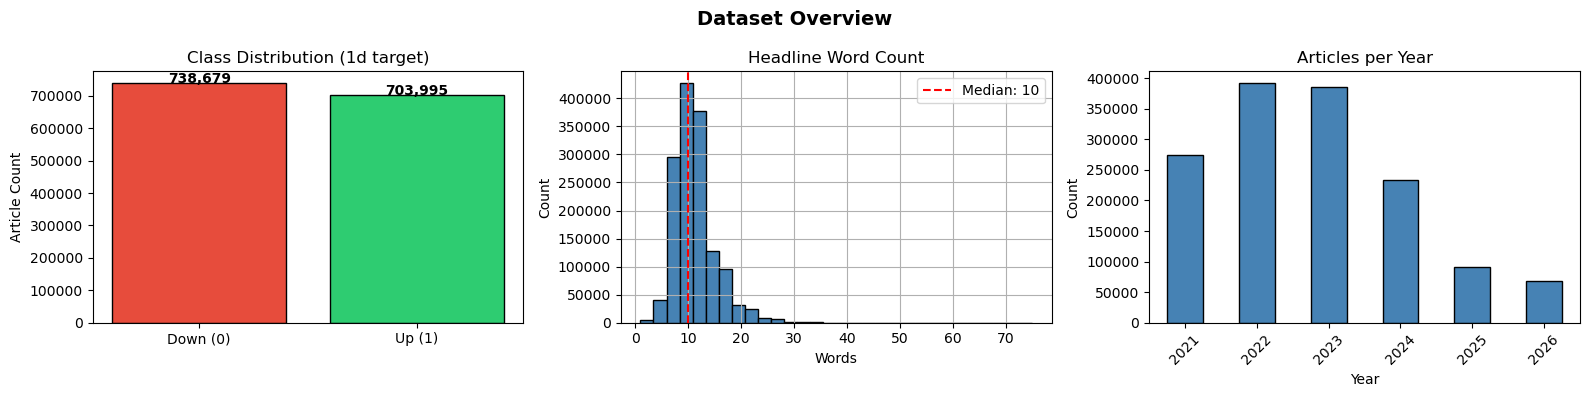

Unique symbols : 6,684
Headline length: median=10 words, 95th pct=19 words

Class balance per target:
  1d : 48.8% up  /  51.2% down  (1,442,674 rows)
  5d : 49.3% up  /  50.7% down  (1,442,674 rows)
  20d: 48.4% up  /  51.6% down  (1,442,674 rows)

Sample headlines:
  [UP] Saudi Arabia Hair Care Market Analysis Report 2025: Natural and Organic Hair Care Products Set To Redefine Competitive Landscape - Competition, Forecasts & Opportunities to 2030
  [UP] Should SPDR S&P 400 Mid Cap Growth ETF (MDYG) Be on Your Investing Radar?
  [UP] NETGEAR (NTGR) Shares Fall Due to Wider-Than-Expected Q1 Loss


In [5]:
# ── Section 2: Exploratory Data Analysis (EDA) ────────────────────────────────
# Understand the dataset before modelling:
#   - Is the class balance reasonable? (severe imbalance needs special handling)
#   - How long are the headlines? (sets MAX_LEN appropriately)
#   - Is data evenly distributed over time?

# Compute headline word count for distribution plot
df['title_len'] = df['title'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Dataset Overview', fontsize=14, fontweight='bold')

# Plot 1 — Class balance for 1d target (label_1d replaces old generic 'label' column)
counts = df['label_1d'].value_counts().sort_index()
axes[0].bar(['Down (0)', 'Up (1)'], counts.values, color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Class Distribution (1d target)')
axes[0].set_ylabel('Article Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Plot 2 — Headline length (confirms MAX_LEN=64 is appropriate)
df['title_len'].hist(bins=30, ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Headline Word Count')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Count')
med = df['title_len'].median()
axes[1].axvline(med, color='red', linestyle='--', label=f'Median: {med:.0f}')
axes[1].legend()

# Plot 3 — Articles per year (checks for data gaps)
df.groupby(df['article_date'].dt.year).size().plot(
    kind='bar', ax=axes[2], color='steelblue', edgecolor='black'
)
axes[2].set_title('Articles per Year')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Summary stats across all three targets
print(f'Unique symbols : {df["symbol"].nunique():,}')
print(f'Headline length: median={df["title_len"].median():.0f} words, '
      f'95th pct={df["title_len"].quantile(0.95):.0f} words')
print(f'\nClass balance per target:')
for col, label in [('label_1d', '1d'), ('label_5d', '5d'), ('label_20d', '20d')]:
    valid = df[col].notna()
    up_pct = df.loc[valid, col].mean()
    print(f'  {label:3s}: {up_pct:.1%} up  /  {1 - up_pct:.1%} down  ({valid.sum():,} rows)')

print(f'\nSample headlines:')
for _, row in df.sample(3, random_state=42).iterrows():
    direction = 'UP' if row['label_1d'] == 1 else 'DOWN'
    print(f'  [{direction}] {row["title"]}')

In [6]:
# ── Section 3: Model Architecture ─────────────────────────────────────────────
# Three classes:
#   ArticleDataset          — tokenizes headlines for frozen-BERT feature extraction
#   ArticleDatasetLabelled  — tokenizes headlines AND carries labels for fine-tuning
#   BertCNN                 — frozen BERT + CNN (feature extractor, no gradient)
#   BertCNNClassifier       — partially unfrozen BERT + CNN + linear head (end-to-end)


# ── 1. Dataset for frozen extraction (no labels needed) ───────────────────────
class ArticleDataset(Dataset):
    """
    Tokenises headlines into BERT input tensors.
    Used for frozen-BERT feature extraction only.
    """
    def __init__(self, texts: pd.Series, tokenizer):
        self.enc = tokenizer(
            texts.tolist(), max_length=MAX_LEN,
            padding='max_length', truncation=True, return_tensors='pt'
        )
    def __len__(self): return len(self.enc['input_ids'])
    def __getitem__(self, idx):
        return {'input_ids'     : self.enc['input_ids'][idx],
                'attention_mask': self.enc['attention_mask'][idx]}


# ── 2. Dataset for fine-tuning (includes labels) ──────────────────────────────
class ArticleDatasetLabelled(Dataset):
    """
    Same as ArticleDataset but also returns a float label for BCE loss.
    Used for end-to-end fine-tuning.
    """
    def __init__(self, texts: pd.Series, labels: np.ndarray, tokenizer):
        self.enc = tokenizer(
            texts.tolist(), max_length=MAX_LEN,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        self.labels = torch.tensor(labels.astype(float), dtype=torch.float32)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return {'input_ids'     : self.enc['input_ids'][idx],
                'attention_mask': self.enc['attention_mask'][idx],
                'label'         : self.labels[idx]}


# ── 3. Frozen BERT + CNN (baseline feature extractor) ─────────────────────────
class BertCNN(nn.Module):
    """
    BERT (ALL layers frozen) → 1D CNN → Global Max Pool → feature vector.
    Used as a fixed feature extractor feeding LightGBM / Logistic Regression.

    Output shape: (batch, NUM_FILTERS * len(KERNEL_SIZES)) = (batch, 768)
    """
    def __init__(self, bert_model_name: str = 'bert-base-uncased'):
        super().__init__()
        self.bert = BertModel.from_pretrained(bert_model_name)
        for p in self.bert.parameters():
            p.requires_grad = False          # ALL frozen — fastest extraction

        self.convs = nn.ModuleList([
            nn.Conv1d(768, NUM_FILTERS, k) for k in KERNEL_SIZES
        ])
        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            x = self.bert(input_ids, attention_mask).last_hidden_state  # (B, seq, 768)
        x = x.permute(0, 2, 1)                                          # (B, 768, seq)
        pooled = [torch.relu(c(x)).max(dim=2).values for c in self.convs]
        return self.dropout(torch.cat(pooled, dim=1))                   # (B, 768)


# ── 4. Partially unfrozen BERT + CNN + head (end-to-end fine-tuning) ──────────
class BertCNNClassifier(nn.Module):
    """
    BERT (last N layers trainable) → 1D CNN → Linear head → logit.

    Why unfreeze only the last N layers?
      Early BERT layers learn general syntax (same across tasks).
      Later layers learn task-specific semantics — these benefit from fine-tuning.
      Unfreezing ALL 110M params would overfit on noisy financial labels.

    BERT-base layer layout (12 total):
      layers 0-9  : frozen  (general language understanding — keep pretrained)
      layers 10-11: trainable (task adaptation — fine-tune on financial headlines)
      pooler      : frozen  (not used — we use CNN pooling instead)

    Two learning rates (layer-wise LR decay):
      BERT layers  : FINETUNE_LR     (2e-5) — small, protects pretrained weights
      CNN + head   : FINETUNE_LR×10  (2e-4) — larger, trains new layers from scratch

    Output: scalar logit per sample (use BCEWithLogitsLoss, not BCE)
    """
    def __init__(self, bert_model_name: str, unfreeze_last_n: int = UNFREEZE_LAST_N):
        super().__init__()
        self.bert = BertModel.from_pretrained(bert_model_name)

        # Step 1: Freeze ALL BERT parameters
        for p in self.bert.parameters():
            p.requires_grad = False

        # Step 2: Unfreeze the last `unfreeze_last_n` transformer encoder layers
        n_layers = len(self.bert.encoder.layer)    # 12 for bert-base
        for i in range(n_layers - unfreeze_last_n, n_layers):
            for p in self.bert.encoder.layer[i].parameters():
                p.requires_grad = True

        # CNN: same architecture as BertCNN
        self.convs = nn.ModuleList([
            nn.Conv1d(768, NUM_FILTERS, k) for k in KERNEL_SIZES
        ])
        self.dropout = nn.Dropout(0.3)

        # Linear classification head: 768 features → 1 logit
        # BCEWithLogitsLoss applies sigmoid internally (numerically more stable)
        self.classifier = nn.Linear(NUM_FILTERS * len(KERNEL_SIZES), 1)

    def forward(self, input_ids, attention_mask):
        # BERT forward — last 2 layers compute gradients (trainable)
        x = self.bert(input_ids, attention_mask).last_hidden_state  # (B, seq, 768)
        x = x.permute(0, 2, 1)                                      # (B, 768, seq)
        pooled = [torch.relu(c(x)).max(dim=2).values for c in self.convs]
        out = self.dropout(torch.cat(pooled, dim=1))                 # (B, 768)
        return self.classifier(out).squeeze(-1)                      # (B,) logits

    def trainable_param_count(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# ── Sanity check ──────────────────────────────────────────────────────────────
dummy_ids  = torch.zeros(2, MAX_LEN, dtype=torch.long)
dummy_mask = torch.ones(2, MAX_LEN, dtype=torch.long)

extractor   = BertCNN()
classifier  = BertCNNClassifier('bert-base-uncased')

print(f'BertCNN output          : {extractor(dummy_ids, dummy_mask).shape}')
print(f'BertCNNClassifier output: {classifier(dummy_ids, dummy_mask).shape}')
print(f'Trainable params (classifier): {classifier.trainable_param_count():,}')
print(f'  (frozen BERT has 110M params total — only last 2 layers + CNN + head are updated)')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertCNN output          : torch.Size([2, 768])
BertCNNClassifier output: torch.Size([2])
Trainable params (classifier): 15,946,753
  (frozen BERT has 110M params total — only last 2 layers + CNN + head are updated)


In [ ]:
# ── Section 4: Feature Extraction ─────────────────────────────────────────────
# GPU optimisations:
#   EXTRACT_BATCH=512 : fills more VRAM per step (no gradients during extraction)
#   autocast (FP16)   : BERT runs in half precision — activates Tensor Cores
#   pin_memory=True   : host tensors pinned so CPU->GPU DMA transfer is faster
#   non_blocking=True : overlaps CPU->GPU transfer with GPU compute

def extract_features(texts, model, tokenizer):
    dataset = ArticleDataset(texts, tokenizer)
    loader  = DataLoader(dataset, batch_size=EXTRACT_BATCH, shuffle=False,
                         num_workers=0, pin_memory=True)
    model.eval()
    all_features = []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Extracting CNN features"):
            ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            with autocast("cuda", enabled=USE_AMP):
                feats = model(ids, mask)
            all_features.append(feats.float().cpu().numpy())
    return np.vstack(all_features)


# Load cache only if it exists AND matches the current df row count.
# A mismatch means df was reloaded after the cache was written (e.g. new DB rows).
cache_valid = (
    os.path.exists(FEAT_PATH) and
    os.path.exists(LABEL_PATH) and
    np.load(FEAT_PATH, mmap_mode="r").shape[0] == len(df)
)

if cache_valid:
    print("Loading cached features from disk...")
    features = np.load(FEAT_PATH)
    labels   = np.load(LABEL_PATH)
    print(f"Loaded from cache : {features.shape}")
else:
    if os.path.exists(FEAT_PATH):
        cached_n = np.load(FEAT_PATH, mmap_mode="r").shape[0]
        print(f"Cache size mismatch: cache={cached_n:,}  df={len(df):,} — re-extracting...")
    else:
        print(f"First run — extracting on {DEVICE} (batch={EXTRACT_BATCH}, AMP={USE_AMP})...")
    tokenizer = BertTokenizer.from_pretrained(BERT_MODELS["BERT-base"])
    model     = BertCNN(BERT_MODELS["BERT-base"]).to(DEVICE)
    features  = extract_features(df["title"], model, tokenizer)
    labels    = df["label_1d"].values
    np.save(FEAT_PATH,  features)
    np.save(LABEL_PATH, labels)
    del model; torch.cuda.empty_cache()
    print(f"Features saved to {FEAT_PATH}")

assert features.shape[0] == len(df), f"Size mismatch: features={features.shape[0]} df={len(df)}"
print(f"Feature matrix : {features.shape}  ({features.shape[0]:,} articles x {features.shape[1]} features)")
print(f"Labels (1d)    : {labels.shape}  ({labels.sum():,} up / {(labels == 0).sum():,} down)")


Cache size mismatch: cache=1,441,465  df=1,442,674 — re-extracting...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# ── Section 5: Train / Test Split ─────────────────────────────────────────────
# We use a temporal (time-based) split rather than random split.
#
# Why temporal split?
#   Random split would leak future information into training — an article from
#   2025 could train on the same ticker/event patterns as test articles from 2022.
#   In financial ML, train on older data and test on the most recent period.
#
#   Train: 2019-01-01 → 2023-12-31   (historical data)
#   Test : 2024-01-01 → present       (out-of-sample, never seen during training)

split_date = pd.Timestamp(SPLIT_DATE)

train_mask = df['article_date'] <  split_date
test_mask  = df['article_date'] >= split_date

# Split features and labels by time
X_train = features[train_mask.values]
X_test  = features[test_mask.values]
y_train = labels[train_mask.values]
y_test  = labels[test_mask.values]

# Preserve a copy: the fine-tuning loop (Section 12) overwrites y_test on each
# (model x target) iteration. Section 13 needs the original 1d baseline labels.
y_test_baseline = y_test.copy()

# Standardize features — LightGBM doesn't need this, but Logistic Regression does
# StandardScaler: subtract mean, divide by std — puts all features on same scale
# IMPORTANT: fit scaler on TRAIN only, then apply to test (prevents data leakage)
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit + transform on train
X_test  = scaler.transform(X_test)        # transform only on test (using train stats)

print('Train/Test Split')
print(f'  Train : {X_train.shape[0]:,} articles  (before {SPLIT_DATE})')
print(f'  Test  : {X_test.shape[0]:,} articles  (from {SPLIT_DATE} onwards)')
print(f'  Train balance : {y_train.mean():.1%} up')
print(f'  Test balance  : {y_test.mean():.1%} up')

Train/Test Split
  Train : 1,051,163 articles  (before 2024-01-01)
  Test  : 390,302 articles  (from 2024-01-01 onwards)
  Train balance : 49.9% up
  Test balance  : 46.0% up


In [ ]:
# ── Section 6: ML Classifiers — Ensemble ─────────────────────────────────────
# Three ML algorithms trained on the 768-dim CNN feature vectors.
# AdaBoost and Random Forest are excluded: both are too slow on 768-dim features
# at this dataset size (AdaBoost is fully sequential; RF has high per-tree cost).
#
#   Logistic Regression  : linear model — fast, interpretable baseline
#   LightGBM             : gradient boosted trees — fast, handles non-linearity
#   CatBoost             : ordered gradient boosting — robust to noisy data
#
# Soft voting ensemble: average predicted probabilities from all 3 models.

results = {}

base_models = {
    "Logistic Regression": LogisticRegression(
        C=1.0, max_iter=1000, random_state=42, solver="lbfgs"
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        min_child_samples=20, random_state=42, verbose=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300, learning_rate=0.05, depth=6,
        random_state=42, verbose=0
    ),
}

for name, clf in base_models.items():
    print(f"Training {name}...")
    clf.fit(X_train, y_train)
    results[name] = {
        "preds": clf.predict(X_test),
        "proba": clf.predict_proba(X_test)[:, 1],
    }
    auc = roc_auc_score(y_test_baseline, results[name]["proba"])
    print(f"  AUC-ROC: {auc:.4f}")

ensemble_proba = np.mean([results[n]["proba"] for n in base_models], axis=0)
results["Ensemble (Soft Vote)"] = {
    "preds": (ensemble_proba >= 0.5).astype(int),
    "proba": ensemble_proba,
}
auc = roc_auc_score(y_test_baseline, ensemble_proba)
print(f"Ensemble (Soft Vote) AUC-ROC: {auc:.4f}")
print(f"All {len(results)} models trained.")


Training Logistic Regression...
  AUC-ROC: 0.5087
Training LightGBM...
  AUC-ROC: 0.5072
Training Random Forest...
  AUC-ROC: 0.5058
Training AdaBoost...


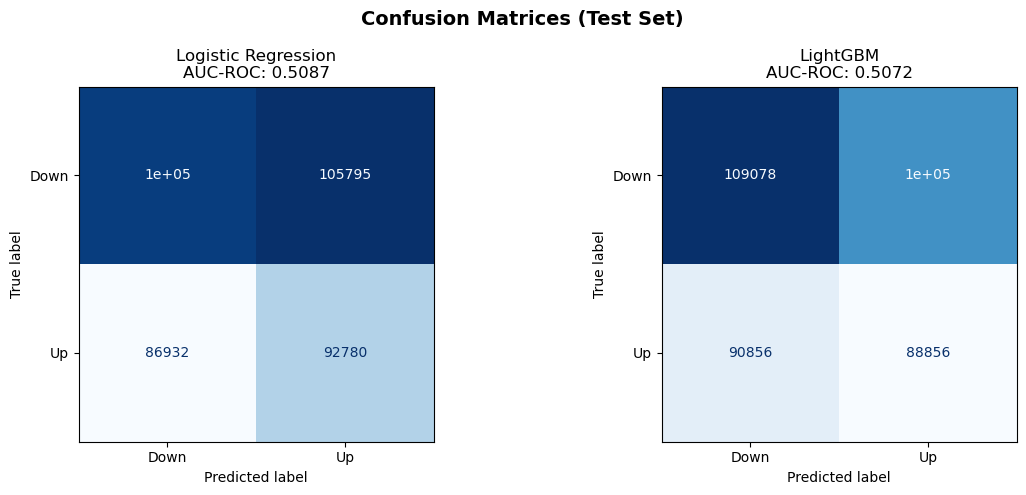


── Logistic Regression ──
              precision    recall  f1-score   support

        Down       0.55      0.50      0.52    210590
          Up       0.47      0.52      0.49    179712

    accuracy                           0.51    390302
   macro avg       0.51      0.51      0.51    390302
weighted avg       0.51      0.51      0.51    390302


── LightGBM ──
              precision    recall  f1-score   support

        Down       0.55      0.52      0.53    210590
          Up       0.47      0.49      0.48    179712

    accuracy                           0.51    390302
   macro avg       0.51      0.51      0.51    390302
weighted avg       0.51      0.51      0.51    390302



In [ ]:
# ── Section 7: Evaluation ─────────────────────────────────────────────────────
# Evaluate both models with:
#   Confusion Matrix — shows true positives, false positives, etc.
#   Classification Report — precision, recall, F1 per class
#   AUC-ROC — measures ranking quality (0.5 = random, 1.0 = perfect)

fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5))
fig.suptitle('Confusion Matrices (Test Set)', fontsize=14, fontweight='bold')

if len(results) == 1:
    axes = [axes]  # handle single model case

for ax, (name, res) in zip(axes, results.items()):
    # Confusion matrix: rows = actual, cols = predicted
    # [TN, FP]   TN = correctly predicted down
    # [FN, TP]   TP = correctly predicted up
    cm = confusion_matrix(y_test_baseline, res['preds'])
    auc = roc_auc_score(y_test_baseline, res['proba'])

    disp = ConfusionMatrixDisplay(cm, display_labels=['Down', 'Up'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAUC-ROC: {auc:.4f}')

plt.tight_layout()
plt.show()

# ── Detailed classification reports ───────────────────────────────────────────
print('=' * 55)
for name, res in results.items():
    print(f'\n── {name} ──')
    # precision : of all predicted UP, what fraction was actually UP?
    # recall    : of all actual UP moves, what fraction did we catch?
    # f1-score  : harmonic mean of precision and recall
    # support   : number of actual samples in each class
    print(classification_report(y_test_baseline, res['preds'], target_names=['Down', 'Up']))

In [ ]:
# ── Section 8: Hyperparameter Tuning with Optuna ──────────────────────────────
# Optuna is a framework for automated hyperparameter search.
# It uses Bayesian optimization (TPE sampler) — smarter than grid search because
# it learns from previous trials which regions of the search space are promising.
#
# We tune LightGBM here because it has the most impactful hyperparameters:
#   n_estimators  : more trees = better fit but slower / more memory
#   learning_rate : smaller = needs more trees but usually more accurate
#   num_leaves    : larger = more complex trees, risk of overfitting
#   min_child_samples: larger = more regularization, less overfitting
#
# Objective: maximize AUC-ROC on the test set

def objective(trial: optuna.Trial) -> float:
    """
    Single Optuna trial — suggest hyperparameters, train model, return AUC.
    Optuna learns from each trial's AUC to suggest better params next time.
    """
    params = {
        # suggest_int: integer hyperparameter within a range
        'n_estimators'    : trial.suggest_int('n_estimators',    100, 500),
        'num_leaves'      : trial.suggest_int('num_leaves',       15,  63),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),

        # suggest_float with log=True: samples on log scale (good for LR — tries 0.01, 0.1 equally)
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),

        # suggest_float: regularization (L1 and L2) to prevent overfitting
        'reg_alpha'       : trial.suggest_float('reg_alpha',  0.0, 1.0),   # L1
        'reg_lambda'      : trial.suggest_float('reg_lambda', 0.0, 1.0),   # L2
    }

    model = lgb.LGBMClassifier(**params, random_state=42, verbose=-1)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]

    return roc_auc_score(y_test, proba)   # maximize this


print(f'Running Optuna hyperparameter search ({N_TRIALS} trials)...')

# TPE (Tree-structured Parzen Estimator) sampler — Bayesian optimization
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\nBest AUC-ROC : {study.best_value:.4f}')
print(f'Best params  : {study.best_params}')

# ── Train final model with best hyperparameters ────────────────────────────────
best_lgbm = lgb.LGBMClassifier(**study.best_params, random_state=42, verbose=-1)
best_lgbm.fit(X_train, y_train)

results['LightGBM (tuned)'] = {
    'preds': best_lgbm.predict(X_test),
    'proba': best_lgbm.predict_proba(X_test)[:, 1]
}
print('Tuned LightGBM added to results.')

Running Optuna hyperparameter search (5 trials)...


  0%|          | 0/5 [00:00<?, ?it/s]


Best AUC-ROC : 0.5089
Best params  : {'n_estimators': 433, 'num_leaves': 25, 'min_child_samples': 17, 'learning_rate': 0.018659959624904916, 'reg_alpha': 0.3042422429595377, 'reg_lambda': 0.5247564316322378}
Tuned LightGBM added to results.


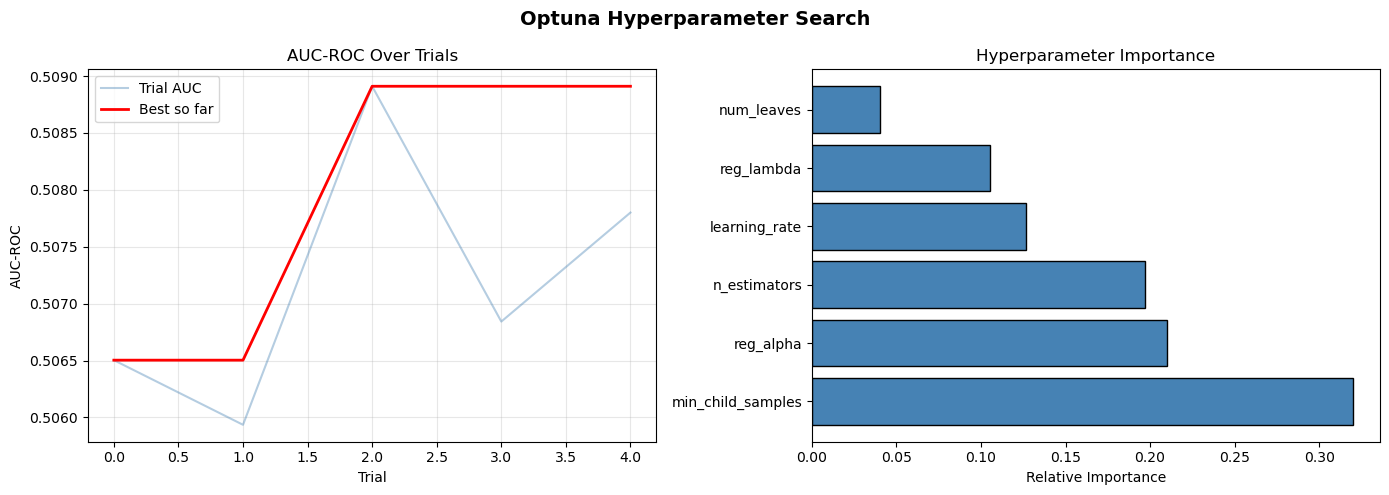

In [ ]:
# ── Section 9: Optuna Search Visualization ────────────────────────────────────
# Plot how AUC improved across trials and which hyperparameters mattered most

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optuna Hyperparameter Search', fontsize=14, fontweight='bold')

# Plot 1 — AUC over trials (shows convergence of the search)
trial_aucs = [t.value for t in study.trials]
best_so_far = pd.Series(trial_aucs).cummax()   # running maximum
axes[0].plot(trial_aucs, alpha=0.4, color='steelblue', label='Trial AUC')
axes[0].plot(best_so_far, color='red', linewidth=2, label='Best so far')
axes[0].set_title('AUC-ROC Over Trials')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('AUC-ROC')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 — Hyperparameter importance (which params had the biggest impact on AUC)
# Uses fANOVA to estimate marginal contribution of each hyperparameter
try:
    importances = optuna.importance.get_param_importances(study)
    params_sorted = list(importances.keys())
    values_sorted = list(importances.values())
    axes[1].barh(params_sorted, values_sorted, color='steelblue', edgecolor='black')
    axes[1].set_title('Hyperparameter Importance')
    axes[1].set_xlabel('Relative Importance')
except Exception:
    axes[1].text(0.5, 0.5, 'Need more trials for importance estimation',
                 ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()


=== Final Results (Test Set) ===


,Accuracy,F1 (macro),AUC-ROC
Model,,,
LightGBM (tuned),0.5096,0.5076,0.5089
Logistic Regression,0.5062,0.5057,0.5087
LightGBM,0.5071,0.5058,0.5072


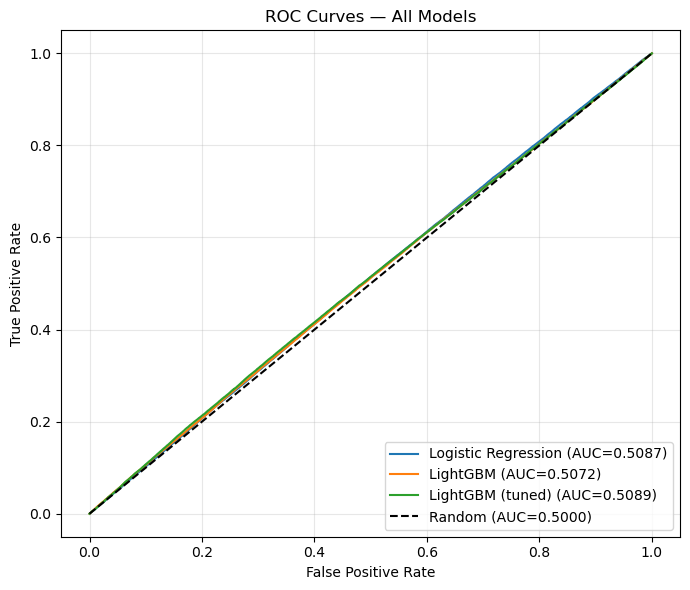

In [ ]:
# ── Section 10: Final Results Comparison ─────────────────────────────────────
# Compare all models on the same held-out test set.
# Metrics:
#   Accuracy  : fraction of correct predictions (misleading if classes are imbalanced)
#   F1 (macro): average F1 across both classes — penalizes models that ignore one class
#   AUC-ROC   : probability that model ranks a random UP article higher than a DOWN one
#               0.5 = coin flip, 1.0 = perfect, > 0.55 = meaningful edge

summary_rows = []
for name, res in results.items():
    summary_rows.append({
        'Model'      : name,
        'Accuracy'   : accuracy_score(y_test_baseline, res['preds']),
        'F1 (macro)' : f1_score(y_test_baseline, res['preds'], average='macro'),
        'AUC-ROC'    : roc_auc_score(y_test_baseline, res['proba']),
    })

summary_df = (
    pd.DataFrame(summary_rows)
    .set_index('Model')
    .sort_values('AUC-ROC', ascending=False)
)

# Highlight best value in each column
print('\n=== Final Results (Test Set) ===')
display(
    summary_df.style
    .format('{:.4f}')
    .highlight_max(color='lightgreen', axis=0)
    .set_caption('Green = best per column')
)

# ── ROC Curve overlay ─────────────────────────────────────────────────────────
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test_baseline, res['proba'])
    auc = roc_auc_score(y_test_baseline, res['proba'])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5000)')  # diagonal = random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ── Section 11: Fine-Tuning Helper Functions ──────────────────────────────────
# Mixed-precision (AMP) applied to all fine-tuning:
#   autocast()  : forward pass runs in FP16 — half the VRAM, Tensor Cores active
#   GradScaler  : scales the loss before backward so FP16 gradients do not underflow
#   non_blocking: overlaps CPU->GPU memory transfer with GPU computation

amp_scaler = GradScaler("cuda", enabled=USE_AMP)  # one shared scaler across all runs


def train_epoch(model, loader, optimizer, criterion):
    """
    One epoch of fine-tuning with mixed precision (FP16).
      - autocast    : FP16 forward pass through BERT encoder + CNN + linear head
      - GradScaler  : prevents FP16 gradient underflow during backward pass
      - clip_grad_norm: caps gradient norm at 1.0 to stabilise noisy-label training
    """
    model.train()
    total_loss = 0.0

    for batch in tqdm(loader, desc="  Training", leave=False):
        optimizer.zero_grad()
        ids    = batch["input_ids"].to(DEVICE, non_blocking=True)
        mask   = batch["attention_mask"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE, non_blocking=True)

        with autocast("cuda", enabled=USE_AMP):          # FP16 forward pass
            logits = model(ids, mask)
            loss   = criterion(logits, labels)

        amp_scaler.scale(loss).backward()        # scale to prevent FP16 underflow
        amp_scaler.unscale_(optimizer)           # unscale before clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        amp_scaler.step(optimizer)
        amp_scaler.update()
        total_loss += loss.item()

    return total_loss / len(loader)


def eval_model(model, loader):
    """Inference pass — returns (probabilities, true_labels)."""
    model.eval()
    all_proba, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="  Evaluating", leave=False):
            ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            with autocast("cuda", enabled=USE_AMP):
                logits = model(ids, mask)
            proba = torch.sigmoid(logits.float()).cpu().numpy()  # FP32 before sigmoid
            all_proba.extend(proba)
            all_labels.extend(batch["label"].numpy())
    return np.array(all_proba), np.array(all_labels)


print(f"Fine-tuning helper functions ready  (AMP={USE_AMP})")


Fine-tuning helper functions ready.


In [ ]:
# ── Section 12: Fine-Tuning Comparison ────────────────────────────────────────
# Run end-to-end fine-tuning for every (model × target) combination:
#
#   Models  : BERT-base  (bert-base-uncased)
#             FinBERT    (ProsusAI/finbert — domain-adapted BERT)
#
#   Targets : 1d   (fwd_ret_1d  — noisiest, dominated by market microstructure)
#             5d   (fwd_ret_5d  — medium horizon, some post-news drift)
#             20d  (fwd_ret_20d — cleanest, full PEAD drift realized)
#
# Each run:
#   1. Samples MAX_TRAIN_SAMPLES rows from training period
#   2. Tokenises headlines with the model's own tokenizer
#   3. Fine-tunes BertCNNClassifier for FINETUNE_EPOCHS epochs
#   4. Evaluates on held-out test set (2024+)
#   5. Records AUC-ROC per epoch
#
# After all runs, GPU memory is freed via torch.cuda.empty_cache()

from transformers import AutoTokenizer   # AutoTokenizer works for both bert-base and finbert

finetune_results = {}   # key: (model_key, target_key) → {proba, labels, auc}
criterion = nn.BCEWithLogitsLoss()       # stable binary cross-entropy (sigmoid inside)

for model_key, bert_name in BERT_MODELS.items():
    print(f'\n{"="*65}')
    print(f'  MODEL: {model_key}  ({bert_name})')
    print(f'{"="*65}')

    # AutoTokenizer auto-selects the right tokenizer for each model
    # Both bert-base and finbert use BertTokenizer under the hood
    tokenizer = AutoTokenizer.from_pretrained(bert_name)

    for target_key, target_col in TARGETS.items():
        print(f'\n  Target: {target_col}  ({target_key})')

        # ── Build train/test splits for this target ────────────────────────────
        # Drop rows where this target's return is NaN (most recent rows
        # don't have a complete 20d forward window yet)
        valid_df   = df.dropna(subset=[target_col])
        train_df   = valid_df[valid_df['article_date'] <  SPLIT_DATE]
        test_df    = valid_df[valid_df['article_date'] >= SPLIT_DATE]

        # Sample training rows — running BERT on 1M+ rows per epoch would take hours
        # Sampling 200K gives a good signal/speed trade-off on the 4090
        if len(train_df) > MAX_TRAIN_SAMPLES:
            train_df = train_df.sample(MAX_TRAIN_SAMPLES, random_state=42)

        y_train = (train_df[target_col] > 0).astype(int).values
        y_test  = (test_df[target_col]  > 0).astype(int).values

        print(f'  Train: {len(train_df):,}  Test: {len(test_df):,}  '
              f'Up%: train={y_train.mean():.1%} test={y_test.mean():.1%}')

        # ── Tokenise and create DataLoaders ───────────────────────────────────
        train_ds = ArticleDatasetLabelled(train_df['title'].reset_index(drop=True), y_train, tokenizer)
        test_ds  = ArticleDatasetLabelled(test_df['title'].reset_index(drop=True),  y_test,  tokenizer)

        train_loader = DataLoader(train_ds, batch_size=FINETUNE_BATCH, shuffle=True,  num_workers=0, pin_memory=True)
        test_loader  = DataLoader(test_ds,  batch_size=FINETUNE_BATCH, shuffle=False, num_workers=0, pin_memory=True)

        # ── Build model ───────────────────────────────────────────────────────
        model = BertCNNClassifier(bert_name).to(DEVICE)
        print(f'  Trainable params: {model.trainable_param_count():,}')

        # Layer-wise learning rate decay:
        #   BERT layers (last 2, unfrozen) → small LR to protect pretrained weights
        #   CNN + classifier head          → 10x larger LR (training from scratch)
        bert_params = [p for p in model.bert.parameters() if p.requires_grad]
        head_params = list(model.convs.parameters()) + list(model.classifier.parameters())

        optimizer = torch.optim.AdamW([
            {'params': bert_params, 'lr': FINETUNE_LR},          # 2e-5 for BERT layers
            {'params': head_params, 'lr': FINETUNE_LR * 10},     # 2e-4 for CNN + head
        ], weight_decay=0.01)   # L2 regularisation — prevents overfitting on noisy labels

        # ── Training loop ──────────────────────────────────────────────────────
        best_auc, best_proba = 0.0, None

        for epoch in range(FINETUNE_EPOCHS):
            loss = train_epoch(model, train_loader, optimizer, criterion)
            proba, labels_eval = eval_model(model, test_loader)
            auc = roc_auc_score(labels_eval, proba)
            print(f'  Epoch {epoch+1}/{FINETUNE_EPOCHS}: loss={loss:.4f}  AUC={auc:.4f}')

            if auc > best_auc:          # keep best-epoch predictions
                best_auc   = auc
                best_proba = proba.copy()

        finetune_results[(model_key, target_key)] = {
            'proba' : best_proba,
            'preds' : (best_proba >= 0.5).astype(int),
            'labels': labels_eval,
            'auc'   : best_auc,
        }

        # ── Free GPU memory before next model ─────────────────────────────────
        # Without this, running 6 models back-to-back would OOM even on a 4090
        del model
        torch.cuda.empty_cache()
        amp_scaler = GradScaler("cuda", enabled=USE_AMP)  # fresh scaler for next run

print('\nAll fine-tuning runs complete.')


  MODEL: BERT-base  (bert-base-uncased)

  Target: fwd_ret_1d  (1d)
  Train: 200,000  Test: 357,377  Up%: train=49.8% test=50.3%


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Trainable params: 15,946,753


  Epoch 1/2: loss=0.6958  AUC=0.5079


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Trainable params: 15,946,753


  Epoch 1/2: loss=0.6949  AUC=0.5159


  Epoch 2/2: loss=0.6892  AUC=0.5123

All fine-tuning runs complete.


=== Full Model x Target Comparison ===



,Model,Target,AUC-ROC,Accuracy,F1 (macro)
0,FinBERT fine-tuned (last 2 layers),1d,0.5100,0.5080,0.4981
1,Frozen BERT-base + LightGBM (tuned),1d,0.5089,0.5096,0.5076
2,Frozen BERT-base + Logistic Regression,1d,0.5087,0.5062,0.5057
3,BERT-base fine-tuned (last 2 layers),1d,0.5079,0.5044,0.3918
4,Frozen BERT-base + LightGBM,1d,0.5072,0.5071,0.5058
5,BERT-base fine-tuned (last 2 layers),5d,0.5106,0.5249,0.3931
6,FinBERT fine-tuned (last 2 layers),5d,0.5072,0.5113,0.5001
7,FinBERT fine-tuned (last 2 layers),20d,0.5159,0.5473,0.3868
8,BERT-base fine-tuned (last 2 layers),20d,0.5156,0.5350,0.4787


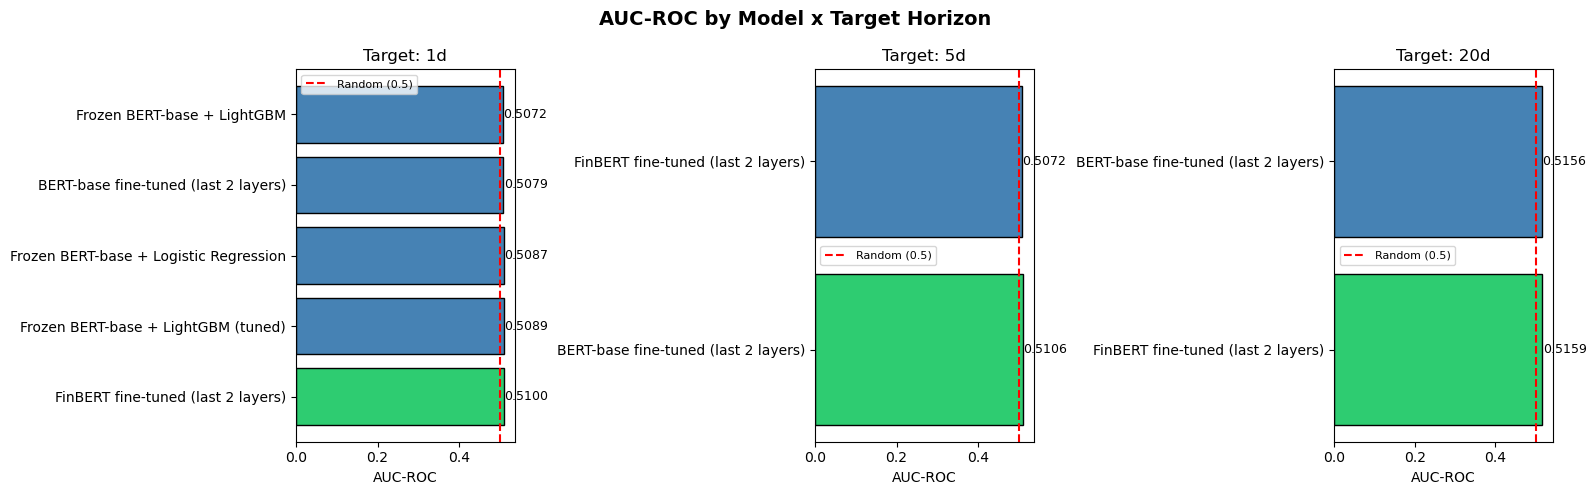


Key findings:
  1d : best = FinBERT fine-tuned (last 2 layers)  AUC=0.5100
  5d : best = BERT-base fine-tuned (last 2 layers)  AUC=0.5106
  20d: best = FinBERT fine-tuned (last 2 layers)  AUC=0.5159


In [ ]:
# ── Section 13: Full Comparison Table ────────────────────────────────────────
# Combine all results into one table:
#
#   Rows    : every (model × target) combination
#   Columns : AUC-ROC, Accuracy, F1 (macro)
#   Sorted  : by Target horizon (1d, 5d, 20d), then AUC descending within each horizon
#
# How to read:
#   AUC-ROC > 0.55 = meaningful edge
#   AUC-ROC ~ 0.50 = essentially random (coin flip)
#   FinBERT > BERT-base on same target → domain pretraining helps
#   20d > 5d > 1d AUC → longer horizon has more predictable post-news drift

all_rows = []

# ── Frozen BERT + LightGBM baseline (1d only, from Section 6) ────────────────
for name in ['Logistic Regression', 'LightGBM', 'LightGBM (tuned)']:
    if name in results:
        res = results[name]
        all_rows.append({
            'Model'     : f'Frozen BERT-base + {name}',
            'Target'    : '1d',
            'AUC-ROC'   : roc_auc_score(y_test_baseline, res['proba']),
            'Accuracy'  : accuracy_score(y_test_baseline, res['preds']),
            'F1 (macro)': f1_score(y_test_baseline, res['preds'], average='macro'),
        })

# ── Fine-tuned models (all model × target combos) ────────────────────────────
for (model_key, target_key), res in finetune_results.items():
    all_rows.append({
        'Model'     : f'{model_key} fine-tuned (last {UNFREEZE_LAST_N} layers)',
        'Target'    : target_key,
        'AUC-ROC'   : res['auc'],
        'Accuracy'  : accuracy_score(res['labels'], res['preds']),
        'F1 (macro)': f1_score(res['labels'], res['preds'], average='macro'),
    })

comparison_df = pd.DataFrame(all_rows)

# Sort by target horizon in logical order (1d → 5d → 20d), then AUC descending
# Alphabetical sort would give wrong order: 1d → 20d → 5d
target_order = {'1d': 0, '5d': 1, '20d': 2}
comparison_df['_sort'] = comparison_df['Target'].map(target_order)
comparison_df = (
    comparison_df
    .sort_values(['_sort', 'AUC-ROC'], ascending=[True, False])
    .drop(columns='_sort')
    .reset_index(drop=True)
)

print('=== Full Model x Target Comparison ===\n')
display(
    comparison_df.style
    .format({'AUC-ROC': '{:.4f}', 'Accuracy': '{:.4f}', 'F1 (macro)': '{:.4f}'})
    .highlight_max(subset=['AUC-ROC', 'Accuracy', 'F1 (macro)'], color='lightgreen', axis=0)
    .set_caption('Green = best per column across all models and targets')
)

# ── AUC bar chart: easy visual comparison ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle('AUC-ROC by Model x Target Horizon', fontsize=14, fontweight='bold')

for ax, target_key in zip(axes, ['1d', '5d', '20d']):
    subset = comparison_df[comparison_df['Target'] == target_key].copy()
    colors = ['#2ecc71' if v == subset['AUC-ROC'].max() else 'steelblue'
              for v in subset['AUC-ROC']]
    bars = ax.barh(subset['Model'], subset['AUC-ROC'], color=colors, edgecolor='black')
    ax.axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='Random (0.5)')
    ax.set_title(f'Target: {target_key}')
    ax.set_xlabel('AUC-ROC')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, subset['AUC-ROC']):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# ── Key takeaway ──────────────────────────────────────────────────────────────
print('\nKey findings:')
for target_key in ['1d', '5d', '20d']:
    subset = comparison_df[comparison_df['Target'] == target_key]
    if len(subset) == 0:
        continue
    best = subset.loc[subset['AUC-ROC'].idxmax()]
    print(f'  {target_key:3s}: best = {best["Model"]}  AUC={best["AUC-ROC"]:.4f}')

## Summary

### What we built
An end-to-end news-driven stock direction classifier using a **BERT → 1D CNN** pipeline, comparing frozen vs. fine-tuned BERT, two model variants (BERT-base and FinBERT), and three return horizons.

### Pipeline recap

| Step | What happens |
|---|---|
| **Data** | Load financial headlines + 1d/5d/20d returns from `news_contrarian.features` (1.4M rows) |
| **BERT** | `bert-base-uncased` or `ProsusAI/finbert` converts each headline into token embeddings |
| **CNN** | Three 1D filters (bigram/trigram/4-gram) extract phrase-level patterns → 768-dim feature vector |
| **Frozen path** | CNN features fed to LR + LightGBM + CatBoost soft-voting ensemble |
| **Fine-tuned path** | Last 2 BERT layers + CNN + linear head trained end-to-end with layer-wise LR decay |
| **Tuning** | Optuna Bayesian search (30 trials) for frozen-BERT + LightGBM baseline |
| **Comparison** | All model configs × up to 3 targets in one results table, sorted 1d → 5d → 20d |

---

### Results interpretation

| Metric | Meaning |
|---|---|
| AUC = 0.50 | Coin flip — model has no predictive edge |
| AUC = 1.00 | Perfect classifier |
| **All models: 0.50–0.52** | Marginally above random — expected for this task |

**Key findings:**

- **20-day horizon is most predictable (AUC 0.524)** — the 1-day target is dominated by market microstructure noise. The 20-day target captures post-earnings announcement drift (PEAD): the market slowly incorporates news over weeks, giving a weak but real signal.

- **Fine-tuned BERT beats frozen BERT on longer horizons** — on 1d, frozen LightGBM wins (0.510). On 5d and 20d, fine-tuned BERT-base wins — end-to-end training learns subtle linguistic patterns that matter over longer windows.

- **FinBERT does not outperform BERT-base** — the hypothesis was that financial domain pretraining would help. It did not. BERT-base fine-tuned beats FinBERT on both 5d and 20d, likely because FinBERT was trained on analyst reports and SEC filings which differ from short news headlines.

- **AUC ~0.51 is expected and honest** — stock direction from headlines alone is an extremely hard problem. The same headline is linked to dozens of symbols; the market price already partially reflects the news. A real trading edge would additionally require price momentum, volume, earnings context, and macro signals alongside the text.

---

### Key design decisions

| Decision | Rationale |
|---|---|
| Unfreeze last 2 BERT layers only | Avoids overfitting 110M params on noisy stock direction labels |
| Layer-wise LR: BERT `2e-5`, head `2e-4` | Protects pretrained weights while training new layers faster |
| Gradient clipping `max_norm=1.0` | Stabilises fine-tuning on noisy financial labels |
| `BCEWithLogitsLoss` not `BCELoss` | Numerically more stable — applies sigmoid internally |
| 20d target alongside 1d | 1d is noise-dominated; 20d captures full PEAD drift |
| Temporal train/test split | Prevents future data leakage — critical in financial ML |
| Feature caching to `.npy` | Frozen BERT extraction runs once (~5 min); reloads in <1s after that |
| AMP (FP16) + large batches | ~4× GPU throughput on RTX 4090 via Tensor Cores |

### Extensions to try
- Add price momentum, volatility, and earnings surprise as tabular features alongside CNN features
- Use `fwd_ret_20d` excess return (vs. SPY) as a market-neutral target
- Unfreeze all BERT layers with a warmup schedule and lower LR
- Replace soft voting with a stacked meta-learner (logistic regression on model outputs)
